##### F. JUMEL

In [35]:
#@title Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
# https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

In [36]:
#@title MIT License
#
# Copyright (c) 2017 François Chollet
#
# Permission is hereby granted, free of charge, to any person obtaining a
# copy of this software and associated documentation files (the "Software"),
# to deal in the Software without restriction, including without limitation
# the rights to use, copy, modify, merge, publish, distribute, sublicense,
# and/or sell copies of the Software, and to permit persons to whom the
# Software is furnished to do so, subject to the following conditions:
#
# The above copyright notice and this permission notice shall be included in
# all copies or substantial portions of the Software.
#
# THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR
# IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY,
# FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL
# THE AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER
# LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING
# FROM, OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER
# DEALINGS IN THE SOFTWARE.

# Basic classification: Classify images from CIFAR10

This guide trains a neural network model to classify different images

This guide uses [tf.keras](https://www.tensorflow.org/guide/keras), a high-level API to build and train models in TensorFlow.

In [2]:
# TensorFlow and tf.keras
import tensorflow as tf

# Helper libraries
import numpy as np
import matplotlib.pyplot as plt

print(tf.__version__)

2.20.0


## Import the CIFAR10  dataset

In [38]:
cifar10 = tf.keras.datasets.cifar10

(train_images, train_labels), (test_images, test_labels) = cifar10.load_data()

Loading the dataset returns four NumPy arrays:

* The `train_images` and `train_labels` arrays are the *training set*—the data the model uses to learn.
* The model is tested against the *test set*, the `test_images`, and `test_labels` arrays.

The images are 32x32x3 NumPy arrays, with pixel values ranging from 0 to 255 (representing RGB channels).
The labels are an array of integers, ranging from 0 to 9, corresponding to the 10 classes in the CIFAR-10 dataset.

Each image is mapped to a single label. Since the *class names* are not included with the dataset, store them here to use later when plotting the images:

In [39]:
class_names = ['Airplane', 'Automobile', 'Bird', 'Cat', 'Deer',
               'Dog', 'Frog', 'Horse', 'Ship', 'Truck']

## Explore the data

Let's explore the format of the dataset before training the model. The following shows there are 50,000 images in the training set, with each image represented as 32 x 32 pixels:

In [40]:
train_images.shape

(50000, 32, 32, 3)

Likewise, there are 60,000 labels in the training set:

In [41]:
len(train_labels)

50000

Each label is an integer between 0 and 9:

In [42]:
train_labels

array([[6],
       [9],
       [9],
       ...,
       [9],
       [1],
       [1]], dtype=uint8)

There are 10,000 images in the test set. Again, each image is represented as 32 x 32 pixels with 3 channels (R,G,B):

In [43]:
test_images.shape

(10000, 32, 32, 3)

And the test set contains 10,000 images labels:

In [44]:
len(test_labels)

10000

## Preprocess the data

The data must be preprocessed before training the network. If you inspect the first image in the training set, you will see that the pixel values fall in the range of 0 to 255 on each channel:

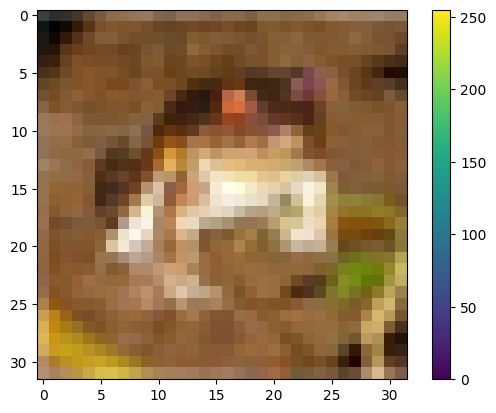

In [45]:
plt.figure()
plt.imshow(train_images[0])
plt.colorbar()
plt.grid(False)
plt.show()

Scale these values to a range of 0 to 1 before feeding them to the neural network model. To do so, divide the values by 255. It's important that the *training set* and the *testing set* be preprocessed in the same way:

In [46]:
train_images = train_images / 255.0

test_images = test_images / 255.0

To verify that the data is in the correct format and that you're ready to build and train the network, let's display the first 25 images from the *training set* and display the class name below each image.

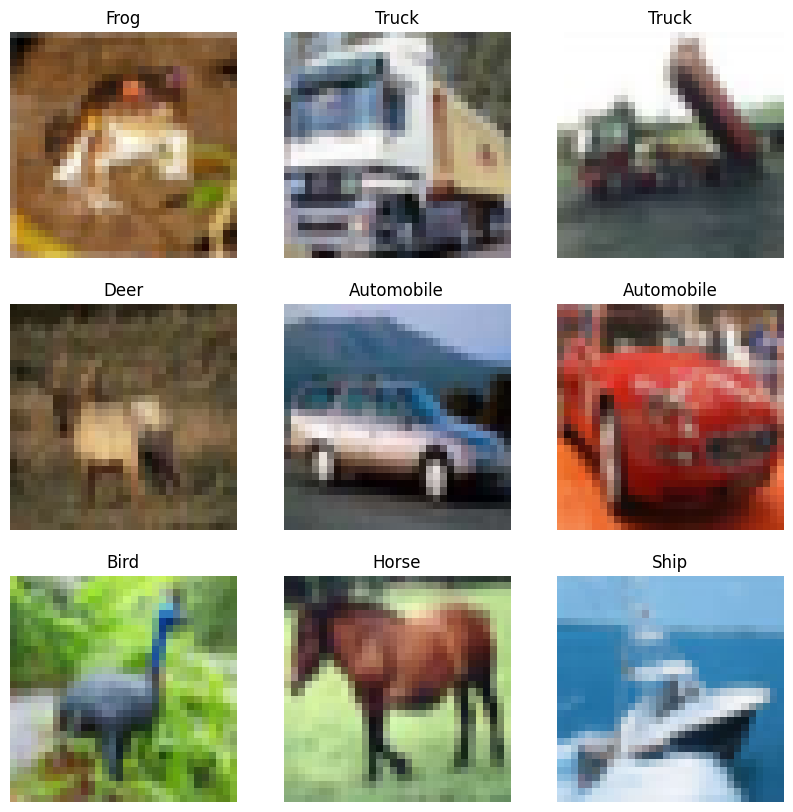

In [47]:
plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(train_images[i])
    plt.title(class_names[train_labels[i][0]])
    plt.axis('off')
plt.show()

## Build the model

Building the neural network requires configuring the layers of the model, then compiling the model.

### Set up the layers

The basic building block of a neural network is the [*layer*](https://www.tensorflow.org/api_docs/python/tf/keras/layers). Layers extract representations from the data fed into them. Hopefully, these representations are meaningful for the problem at hand.

Most of deep learning consists of chaining together simple layers. Most layers, such as `tf.keras.layers.Dense`, have parameters that are learned during training.

In [13]:
def create_simplest_cifar10_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(32, 32, 3)),  # Ajout de la couche d'entrée
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(10)
    ], name="Simplest_NN_CIFAR10_Model")
    return model

def create_vanilla_nn_cifar10_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(32, 32, 3)),  # Ajout de la couche d'entrée
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(10)
    ], name="Vanilla_NN_CIFAR10_Model")
    return model

def create_lenet5_cifar10_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(32, 32, 3)),  # Ajout de la couche d'entrée
        tf.keras.layers.Conv2D(6, kernel_size=(5, 5), activation='tanh'),
        tf.keras.layers.AveragePooling2D(pool_size=(2, 2)),
        tf.keras.layers.Conv2D(16, kernel_size=(5, 5), activation='tanh'),
        tf.keras.layers.AveragePooling2D(pool_size=(2, 2)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(120, activation='tanh'),
        tf.keras.layers.Dense(84, activation='tanh'),
        tf.keras.layers.Dense(10)
    ], name="Lenet5_CIFAR10_Model")
    return model

def create_vanilla_cnn_cifar10_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(32, 32, 3)),  # Ajout de la couche d'entrée
        tf.keras.layers.Conv2D(32, kernel_size=(3, 3), activation='relu', padding='same'),
        tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
        tf.keras.layers.Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same'),
        tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
        tf.keras.layers.Conv2D(128, kernel_size=(3, 3), activation='relu', padding='same'),
        tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(10)
    ], name="Vanilla_CNN_CIFAR10_Model")
    return model

def create_alexnet_cifar10_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(32, 32, 3)),  # Ajout de la couche d'entrée
        tf.keras.layers.Conv2D(96, kernel_size=(3, 3), activation='relu', padding='same'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)),
        tf.keras.layers.Conv2D(256, kernel_size=(3, 3), activation='relu', padding='same'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)),
        tf.keras.layers.Conv2D(384, kernel_size=(3, 3), activation='relu', padding='same'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Conv2D(384, kernel_size=(3, 3), activation='relu', padding='same'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Conv2D(256, kernel_size=(3, 3), activation='relu', padding='same'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(4096, activation='relu'),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(4096, activation='relu'),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(10)
    ], name="AlexNet_CIFAR10_Model")
    return model

# Créer les modèles
model_simplest = create_simplest_cifar10_model()
model_vanilla_nn = create_vanilla_nn_cifar10_model()
model_lenet5 = create_lenet5_cifar10_model()
model_vanilla_cnn = create_vanilla_cnn_cifar10_model()
model_alexnet = create_alexnet_cifar10_model()

# Afficher le résumé d'un modèle
model = model_vanilla_cnn
model.summary()


Model: "Vanilla_CNN_CIFAR10_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,810 (1.36 MB)

 Trainable params: 356,810 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999, epsilon=1e-07, amsgrad=False, name='Adam'),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

## Train the model

Training the neural network model requires the following steps:

1. Feed the training data to the model. In this example, the training data is in the `train_images` and `train_labels` arrays.
2. The model learns to associate images and labels.
3. You ask the model to make predictions about a test set—in this example, the `test_images` array.
4. Verify that the predictions match the labels from the `test_labels` array.


### Feed the model

To start training,  call the [`model.fit`](https://www.tensorflow.org/api_docs/python/tf/keras/Model#fit) method—so called because it "fits" the model to the training data:

In [16]:
model.fit(
    train_images,  # Training images
    train_labels,  # Corresponding labels
    batch_size=32,  # Default batch size, meaning the number of samples processed before a model update
    epochs=10,  # Number of epochs (full passes over the dataset)
    verbose=1,  # Verbosity level (1 = displays training progress)
    validation_split=0.0,  # No validation set is generated from the training data
    shuffle=True,  # Shuffles the training data before each epoch
    callbacks=None  # No callbacks are used for specific actions during training
)


Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.4639 - loss: 1.7542
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.6105 - loss: 1.1146
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.6601 - loss: 0.9802
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.6941 - loss: 0.8874
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7177 - loss: 0.8118
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.7401 - loss: 0.7500
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7603 - loss: 0.6883
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.7777 - loss: 0.6410
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.7965 - loss: 0.5897
Epoch 10/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8095 - loss: 0.5535


### Evaluate accuracy

Next, compare how the model performs on the test dataset:

In [51]:
test_loss, test_acc = model.evaluate(test_images,  test_labels, verbose=2)

print('\nTest accuracy:', test_acc)

313/313 - 3s - 8ms/step - accuracy: 0.7479 - loss: 0.8909

Test accuracy: 0.7479000091552734


It turns out that the accuracy on the test dataset is a little less than the accuracy on the training dataset. This gap between training accuracy and test accuracy represents *overfitting*. Overfitting happens when a machine learning model performs worse on new, previously unseen inputs than it does on the training data. An overfitted model "memorizes" the noise and details in the training dataset to a point where it negatively impacts the performance of the model on the new data. For more information, see the following:
*   [Demonstrate overfitting](https://www.tensorflow.org/tutorials/keras/overfit_and_underfit#demonstrate_overfitting)
*   [Strategies to prevent overfitting](https://www.tensorflow.org/tutorials/keras/overfit_and_underfit#strategies_to_prevent_overfitting)

### Make predictions

With the model trained, you can use it to make predictions about some images.
Attach a softmax layer to convert the model's linear outputs—[logits](https://developers.google.com/machine-learning/glossary#logits)—to probabilities, which should be easier to interpret. Rq: Its classical to add directly the softmax in the output of the model (tf.keras.layers.Dense(10, activation='softmax') but in this case change from_logits=True to from_logits=False  )

In [52]:
probability_model = tf.keras.Sequential([model,
                                         tf.keras.layers.Softmax()])

In [53]:
predictions = probability_model.predict(test_images)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


Here, the model has predicted the label for each image in the testing set. Let's take a look at the first prediction:

In [54]:
predictions[0]

array([1.4283203e-05, 1.4789533e-04, 1.1692234e-04, 8.2758844e-01,
       8.2892988e-08, 1.5357482e-01, 1.7607827e-02, 2.5708761e-07,
       9.4119814e-04, 8.1858925e-06], dtype=float32)

A prediction is an array of 10 numbers. They represent the model's "confidence" that the image corresponds to each of the 10 different articles of clothing. You can see which label has the highest confidence value:

In [55]:
np.argmax(predictions[0])

np.int64(3)

So, the model is most confident that this image is an ankle boot, or `class_names[9]`. Examining the test label shows that this classification is correct:

In [56]:
test_labels[0].item()

3

Define functions to graph the full set of 10 class predictions.

In [57]:
def plot_image(i, predictions_array, true_label, img):
    true_label = test_labels[i].item()  # Extraire le label vrai pour l'index i
    plt.imshow(img[i], cmap=plt.cm.binary)
    predicted_label = np.argmax(predictions_array)  # Prendre le label prédit
    color = 'blue' if predicted_label == true_label else 'red'

    plt.xlabel("{} {:2.0f}% ({})".format(class_names[predicted_label],
                                         100*np.max(predictions_array),
                                         class_names[true_label]),  # Utiliser true_label directement
               color=color)

def plot_value_array(i, predictions_array, true_label):
  true_label = true_label[i].item()
  plt.grid(False)
  plt.xticks(range(10))
  plt.yticks([])
  thisplot = plt.bar(range(10), predictions_array, color="#777777")
  plt.ylim([0, 1])
  predicted_label = np.argmax(predictions_array)

  thisplot[predicted_label].set_color('red')
  thisplot[true_label].set_color('blue')

### Verify predictions

With the model trained, you can use it to make predictions about some images.

Let's look at the 0th image, predictions, and prediction array. Correct prediction labels are blue and incorrect prediction labels are red. The number gives the percentage (out of 100) for the predicted label.

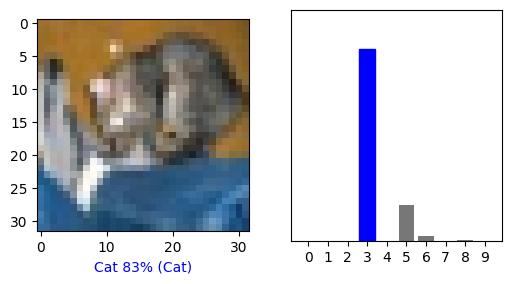

In [58]:
i = 0
plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
plot_image(i, predictions[i], test_labels, test_images)
plt.subplot(1,2,2)
plot_value_array(i, predictions[i],  test_labels)
plt.show()

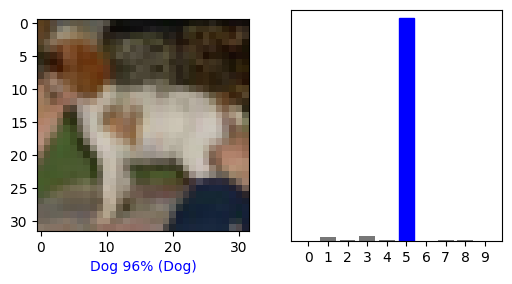

In [59]:
i = 12
plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
plot_image(i, predictions[i], test_labels, test_images)
plt.subplot(1,2,2)
plot_value_array(i, predictions[i],  test_labels)
plt.show()

Let's plot several images with their predictions. Note that the model can be wrong even when very confident.

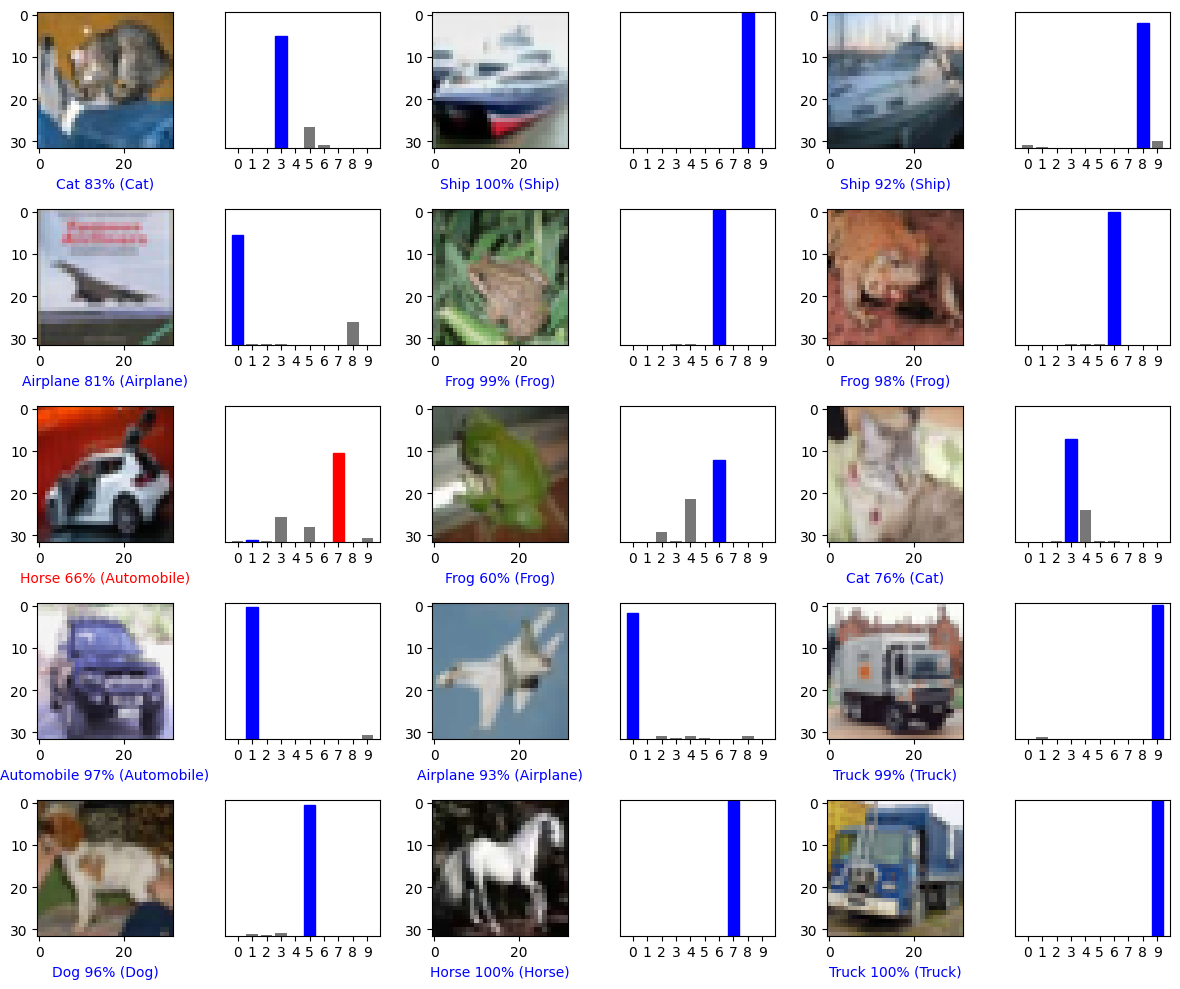

In [60]:
# Plot the first X test images, their predicted labels, and the true labels.
# Color correct predictions in blue and incorrect predictions in red.
num_rows = 5
num_cols = 3
num_images = num_rows*num_cols
plt.figure(figsize=(2*2*num_cols, 2*num_rows))
for i in range(num_images):
  plt.subplot(num_rows, 2*num_cols, 2*i+1)
  plot_image(i, predictions[i], test_labels, test_images)
  plt.subplot(num_rows, 2*num_cols, 2*i+2)
  plot_value_array(i, predictions[i], test_labels)
plt.tight_layout()
plt.show()

## Use the trained model

Finally, use the trained model to make a prediction about a single image.

In [61]:
# Grab an image from the test dataset.
img = test_images[1]

print(img.shape)

(32, 32, 3)


`tf.keras` models are optimized to make predictions on a *batch*, or collection, of examples at once. Accordingly, even though you're using a single image, you need to add it to a list:

In [62]:
# Add the image to a batch where it's the only member.
img = (np.expand_dims(img,0))

print(img.shape)

(1, 32, 32, 3)


Now predict the correct label for this image:

In [63]:
predictions_single = probability_model.predict(img)

print(predictions_single)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 557ms/step
[[3.6692675e-06 4.9773941e-04 3.6277461e-12 9.8982944e-10 2.5045084e-11
  1.7106648e-11 6.8458095e-12 2.3005432e-14 9.9949813e-01 4.4849807e-07]]


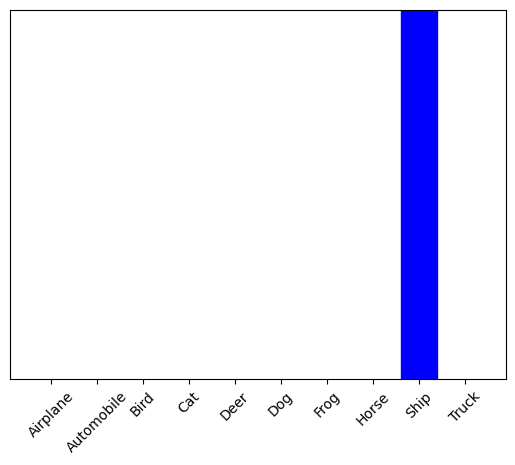

In [64]:
plot_value_array(1, predictions_single[0], test_labels)
_ = plt.xticks(range(10), class_names, rotation=45)
plt.show()

`tf.keras.Model.predict` returns a list of lists—one list for each image in the batch of data. Grab the predictions for our (only) image in the batch:

In [65]:
np.argmax(predictions_single[0])

np.int64(8)

And the model predicts a label as expected.

To learn more about building models with Keras, see the [Keras guides](https://www.tensorflow.org/guide/keras).

## Matrix Confusion
### Check the consistency of the test dataset.
 As we will use percentages next, first ensure that the test dataset is homogeneous

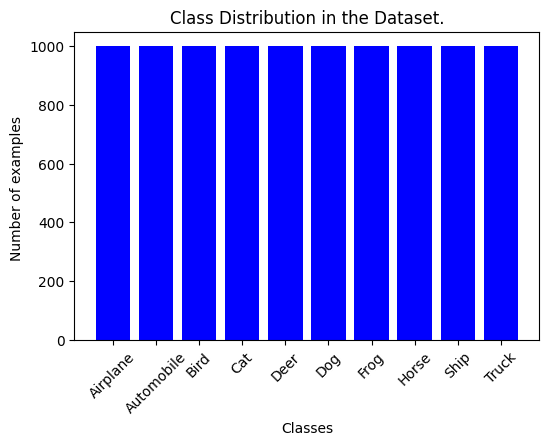

In [66]:
def plot_class_distribution(labels, class_names):
    # Convertir les labels en un tableau 1D si nécessaire
    labels_flat = labels.flatten()

    # Compter les occurrences de chaque classe
    class_counts = np.bincount(labels_flat)

    # Affichage de la répartition des classes
    plt.figure(figsize=(6, 4))
    plt.bar(class_names, class_counts, color='blue')
    plt.xlabel('Classes')
    plt.ylabel('Number of examples ')
    plt.title('Class Distribution in the Dataset.')
    plt.xticks(rotation=45)
    plt.show()
plot_class_distribution(test_labels, class_names)


### Confusion Matrix


A confusion matrix is a powerful tool used to evaluate the performance of a classification model. It provides a summary of the prediction results, comparing the actual labels with the predicted labels. In this context, particularly when working with a model for image classification (like CIFAR-10), the confusion matrix helps us understand how well the model distinguishes between different classes.

Each row of the matrix represents the instances of an actual class, while each column represents the instances of a predicted class. The diagonal elements indicate the number of correct predictions for each class, while the off-diagonal elements represent misclassifications.

By converting the counts in the confusion matrix to percentages, we can gain deeper insights into the model's performance, allowing us to identify which classes are often confused with one another. This analysis is crucial for improving the model's accuracy and making informed decisions about further training or adjustments needed to enhance classification performance.

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


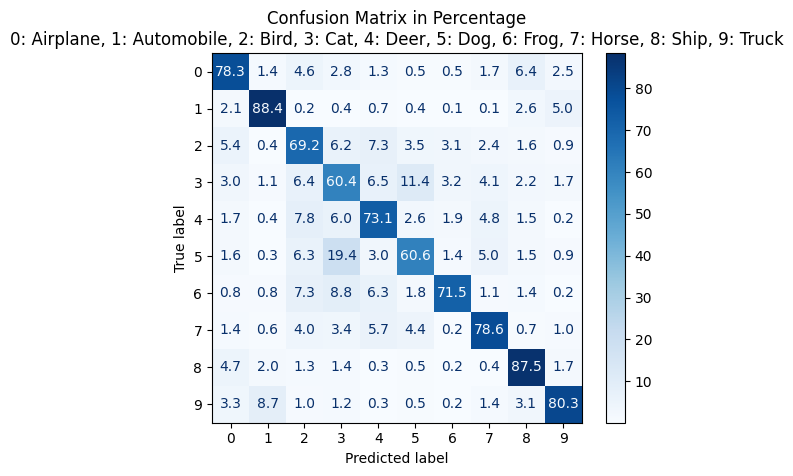

In [67]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

# Prédictions avec le modèle
predictions = model.predict(test_images)
predicted_classes = np.argmax(predictions, axis=1)

# Calculer la matrice de confusion et la normaliser en pourcentage
cm = confusion_matrix(test_labels, predicted_classes)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100  # Convertir en pourcentages

# Afficher la matrice de confusion normalisée
disp = ConfusionMatrixDisplay(confusion_matrix=cm_normalized, display_labels=np.arange(10))
disp.plot(cmap=plt.cm.Blues, values_format=".1f")  # Afficher les pourcentages avec 2 décimales

# Légende  classes

class_list = ", ".join([f"{i}: {class_name}" for i, class_name in enumerate(class_names)])
plt.title(f'Confusion Matrix in Percentage\n{class_list}')

plt.show()


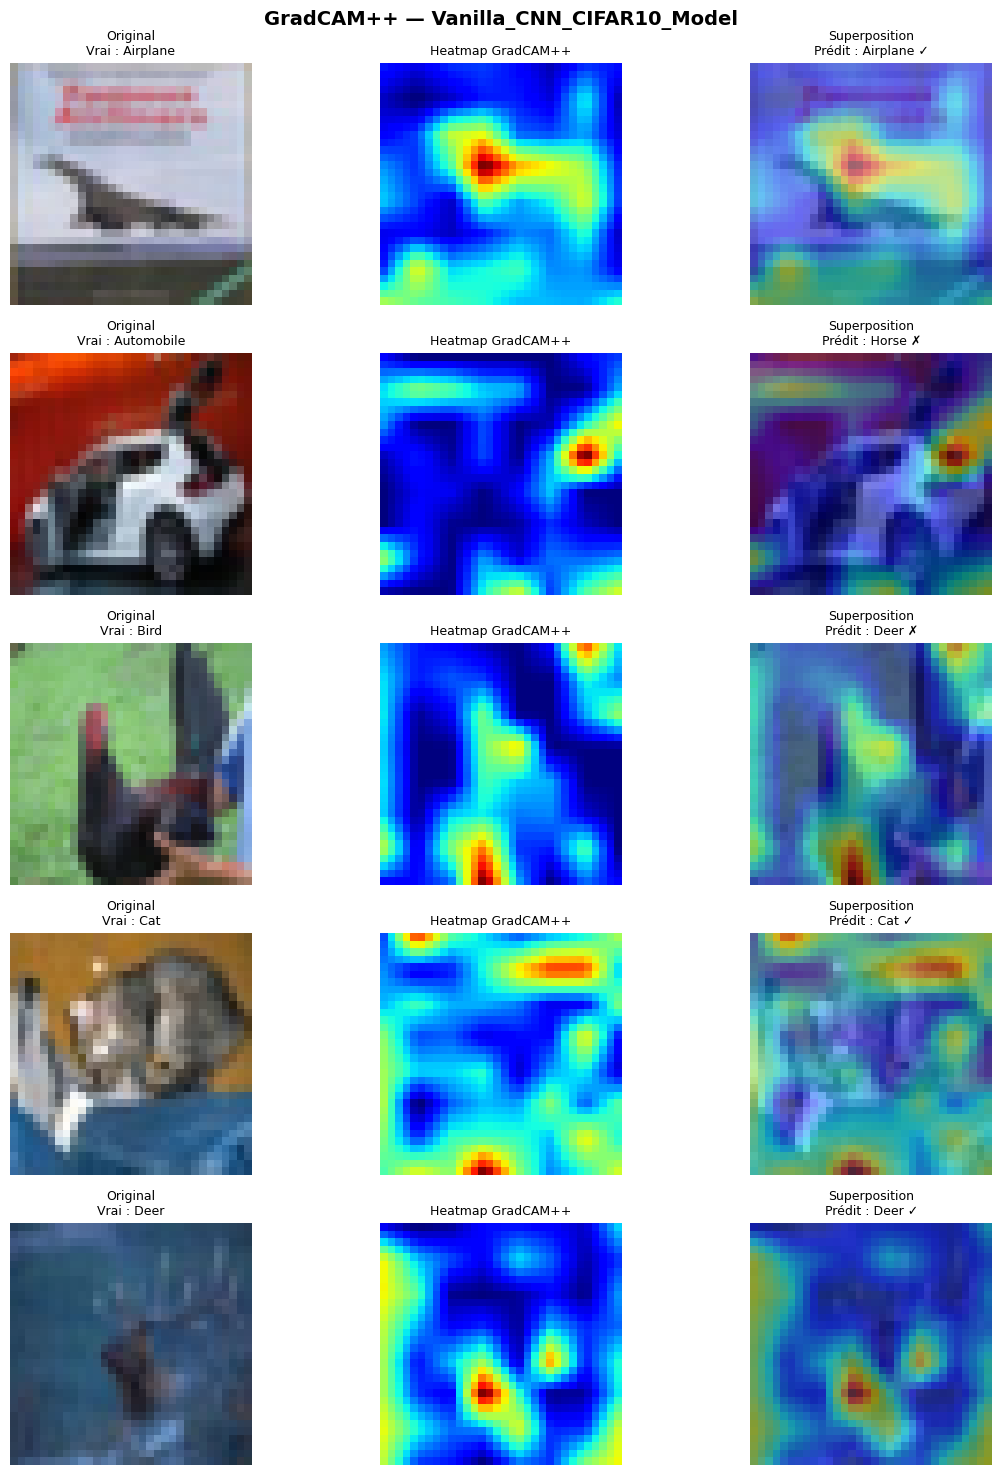

Figure sauvegardée : gradcam_vanilla_cnn_cifar10_model.png


In [69]:
!pip install tf-keras-vis -q

from tf_keras_vis.gradcam_plus_plus import GradcamPlusPlus
from tf_keras_vis.utils.scores import CategoricalScore
from tf_keras_vis.utils.model_modifiers import ReplaceToLinear
import matplotlib.cm as cm

def apply_gradcam_plus_plus(model, images, labels, class_names, num_images=5, model_name=""):

    def model_modifier(m):
        m.layers[-1].activation = tf.keras.activations.linear
        return m

    gradcam = GradcamPlusPlus(model, model_modifier=model_modifier, clone=True)

    indices = []
    for c in range(10):
        candidates = np.where(labels.flatten() == c)[0]
        if len(candidates) > 0:
            indices.append(candidates[0])
        if len(indices) >= num_images:
            break

    fig, axes = plt.subplots(num_images, 3, figsize=(12, num_images * 3))
    fig.suptitle(f'GradCAM++ — {model_name}', fontsize=14, fontweight='bold')

    for row, idx in enumerate(indices):
        img = test_images[idx]
        true_label = int(labels[idx].flatten()[0])
        input_tensor = np.expand_dims(img, 0)

        preds = model.predict(input_tensor, verbose=0)
        pred_label = int(np.argmax(preds[0]))

        score = CategoricalScore([true_label])
        cam = gradcam(score, input_tensor)
        heatmap = cam[0]

        heatmap_colored = cm.jet(heatmap)[..., :3]

        overlay = 0.5 * img + 0.5 * heatmap_colored
        overlay = np.clip(overlay, 0, 1)

        # Colonne 0 : image originale
        axes[row, 0].imshow(img)
        axes[row, 0].set_title(f"Original\nVrai : {class_names[true_label]}", fontsize=9)
        axes[row, 0].axis('off')

        # Colonne 1 : heatmap seule
        axes[row, 1].imshow(heatmap, cmap='jet')
        axes[row, 1].set_title("Heatmap GradCAM++", fontsize=9)
        axes[row, 1].axis('off')

        # Colonne 2 : superposition
        correct = "✓" if pred_label == true_label else "✗"
        axes[row, 2].imshow(overlay)
        axes[row, 2].set_title(
            f"Superposition\nPrédit : {class_names[pred_label]} {correct}", fontsize=9
        )
        axes[row, 2].axis('off')

    plt.tight_layout()
    plt.savefig(f'gradcam_{model_name.lower().replace(" ","_")}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Figure sauvegardée : gradcam_{model_name.lower().replace(' ','_')}.png")


apply_gradcam_plus_plus(model,     test_images, test_labels, class_names,
                        num_images=5, model_name=model.name)


In [4]:
# fashion_MNIST
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.fashion_mnist.load_data()
train_images = train_images[..., np.newaxis] / 255.0
test_images  = test_images[..., np.newaxis]  / 255.0

model_fashion_mnist = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28, 1)),
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10)
])
model_fashion_mnist.compile(optimizer='adam',
                    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                    metrics=['accuracy'])
model_fashion_mnist.fit(train_images, train_labels, batch_size=256, epochs=20)
loss, acc = model_fashion_mnist.evaluate(test_images, test_labels)
print(f"fashion_MNIST test accuracy: {acc:.4f}")

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.8003 - loss: 0.5635
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8785 - loss: 0.3431
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8936 - loss: 0.2977
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9029 - loss: 0.2704
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9130 - loss: 0.2448
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9176 - loss: 0.2285
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9207 - loss: 0.2171
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9274 - loss: 0.1993
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9309 - loss: 0.1886
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━

In [5]:
# CIFAR-100
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.cifar100.load_data()
train_images = train_images / 255.0
test_images  = test_images  / 255.0

model_cifar100 = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(32, 32, 3)),
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(100)  # 100 classes !
])
model_cifar100.compile(optimizer='adam',
                       loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                       metrics=['accuracy'])
model_cifar100.fit(train_images, train_labels, batch_size=256, epochs=50)
loss, acc = model_cifar100.evaluate(test_images, test_labels)
print(f"CIFAR-100 test accuracy: {acc:.4f}")

169001437/169001437 ━━━━━━━━━━━━━━━━━━━━ 19s 0us/step
Epoch 1/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.1043 - loss: 3.9461
Epoch 2/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.2318 - loss: 3.1896
Epoch 3/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.2954 - loss: 2.8364
Epoch 4/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.3507 - loss: 2.5879
Epoch 5/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.3899 - loss: 2.4015
Epoch 6/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.4227 - loss: 2.2434
Epoch 7/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.4535 - loss: 2.1036
Epoch 8/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.4817 - loss: 1.9755
Epoch 9/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.5081 - loss: 1.8511
Epoch 10/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.5343 - loss: 1.7384
Epoch 11/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.5633 - 

In [8]:
# Dataset 4 : CIFAR-10 avec Data Augmentation
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.cifar10.load_data()
train_images = train_images / 255.0
test_images  = test_images  / 255.0

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

model_augmented = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(32, 32, 3)),
    data_augmentation,
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10)
])
model_augmented.compile(optimizer='adam',
                        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                        metrics=['accuracy'])
model_augmented.fit(train_images, train_labels, batch_size=256, epochs=50)
loss, acc = model_augmented.evaluate(test_images, test_labels)
print(f"CIFAR-10 augmenté test accuracy: {acc:.4f}")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step
Epoch 1/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.3688 - loss: 1.7465
Epoch 2/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.4752 - loss: 1.4599
Epoch 3/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.5289 - loss: 1.3187
Epoch 4/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.5672 - loss: 1.2264
Epoch 5/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.5941 - loss: 1.1500
Epoch 6/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.6120 - loss: 1.1071
Epoch 7/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.6317 - loss: 1.0552
Epoch 8/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.6402 - loss: 1.0232
Epoch 9/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.6565 - loss: 0.9857
Epoch 10/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.6649 - loss: 0.9611
Epoch 11/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.6747 -

In [9]:
# Vérification : taille originale de CIFAR-10
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.cifar10.load_data()
print(f"Train : {train_images.shape}")  # attendu : (50000, 32, 32, 3)
print(f"Test  : {test_images.shape}")   # attendu : (10000, 32, 32, 3)
print(f"Total : {train_images.shape[0] + test_images.shape[0]} images")

Train : (50000, 32, 32, 3)
Test  : (10000, 32, 32, 3)
Total : 60000 images


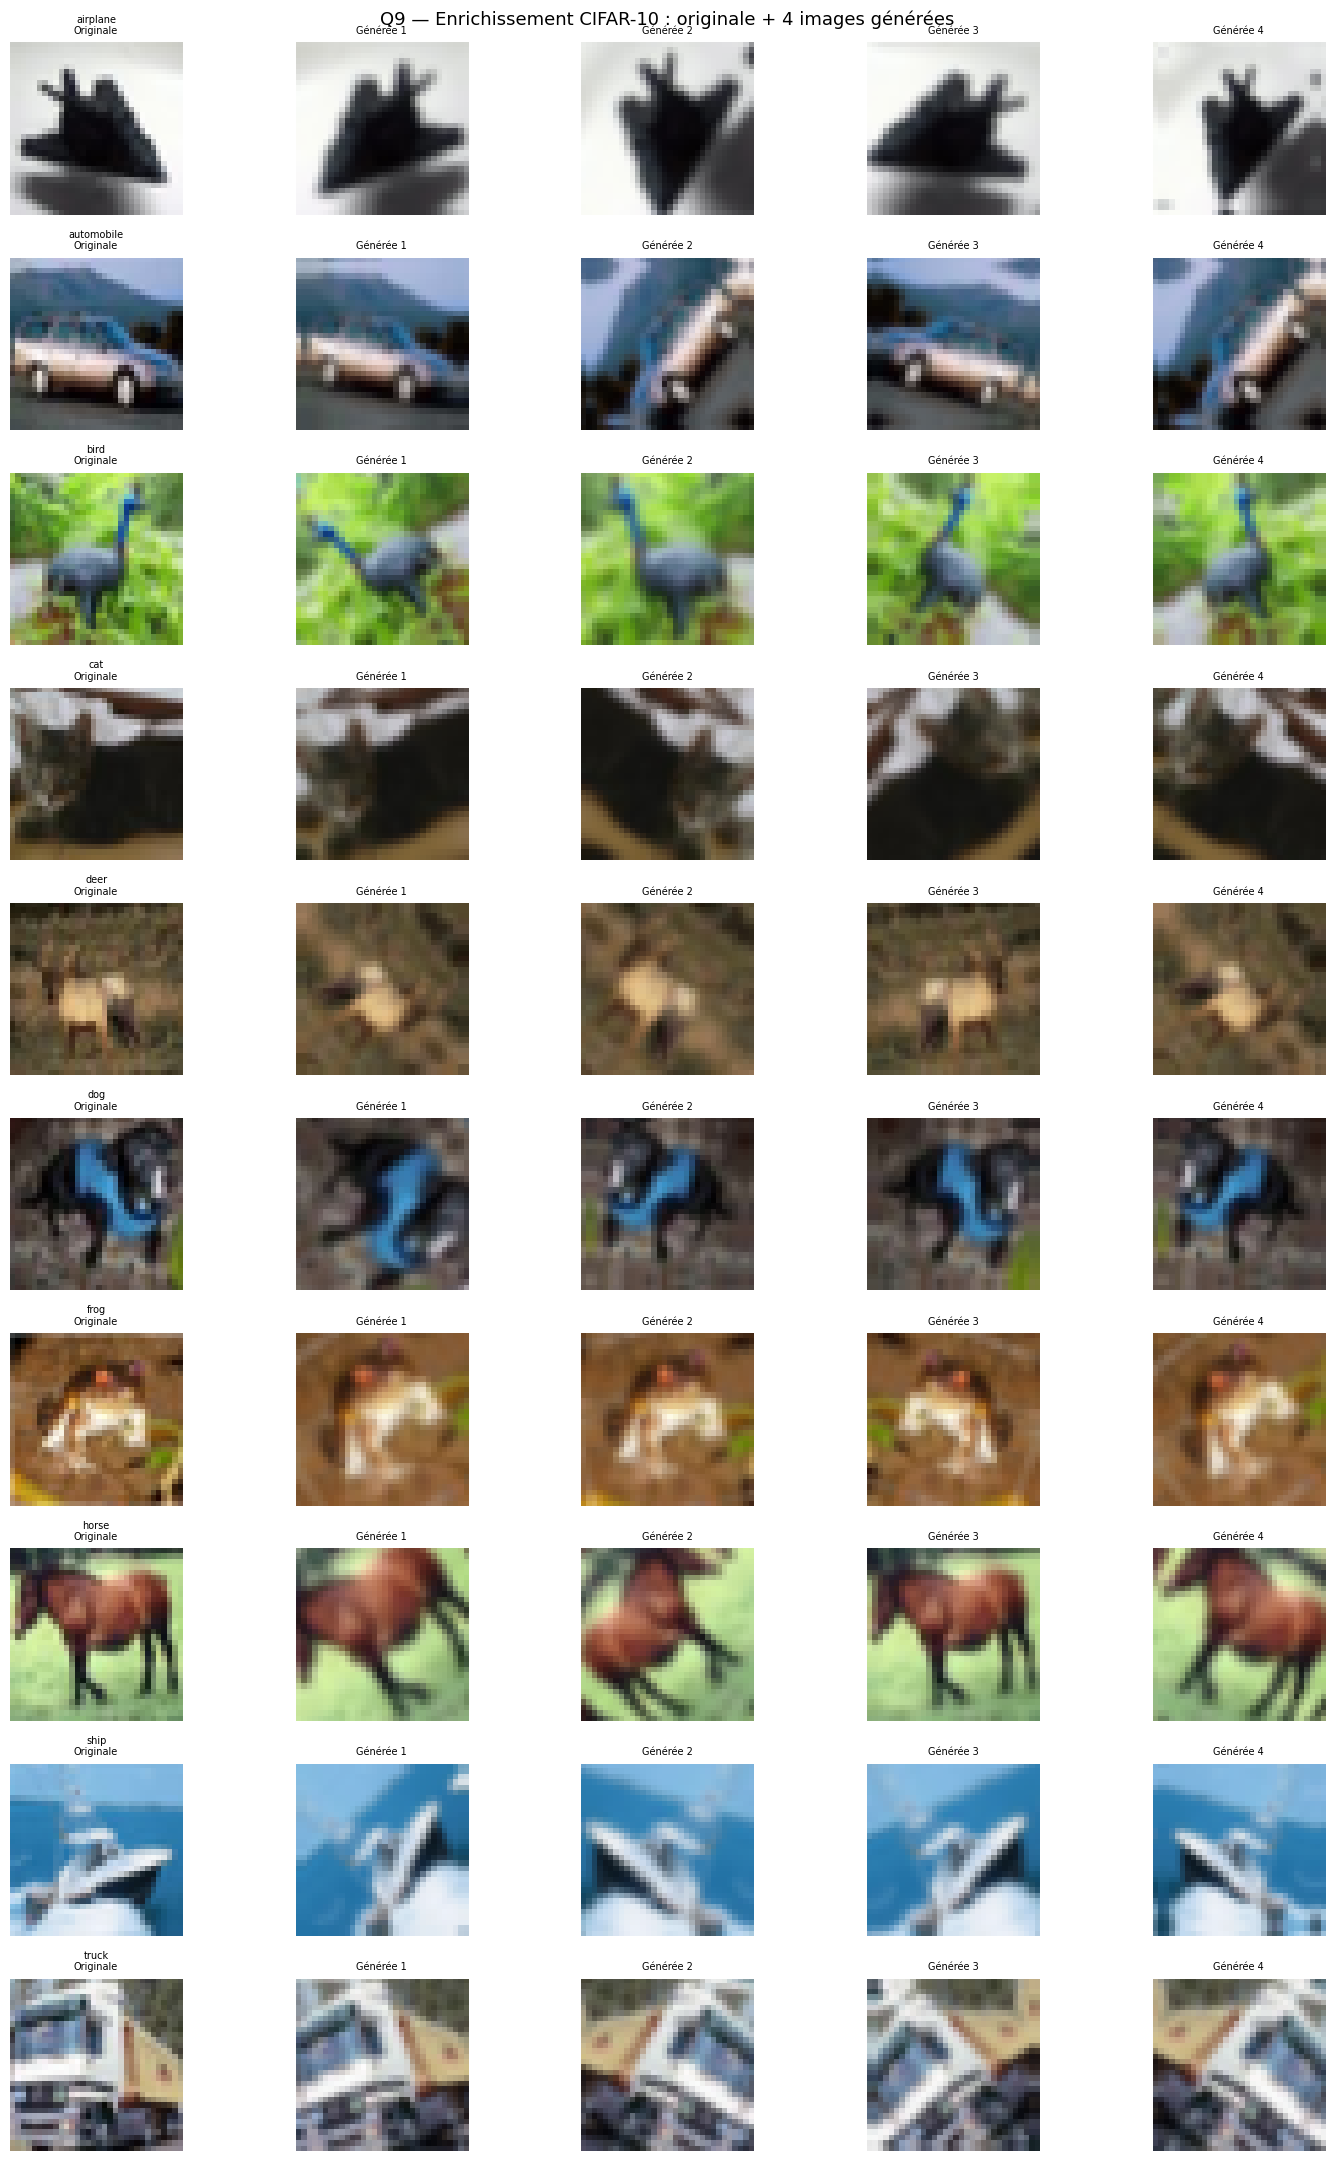

Images générées : 40 (4 par classe × 10 classes)


In [11]:
import os
import matplotlib.pyplot as plt

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

augment = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.15),
    tf.keras.layers.RandomZoom(0.15),
])

train_images_norm = train_images / 255.0

fig, axes = plt.subplots(10, 5, figsize=(15, 22))
fig.suptitle("Q9 — Enrichissement CIFAR-10 : originale + 4 images générées", fontsize=13)

new_images = []
new_labels = []

for class_idx in range(10):
    # Prendre la première image de la classe
    idx = np.where(train_labels.flatten() == class_idx)[0][0]
    original = train_images_norm[idx]

    # Afficher l'originale
    axes[class_idx, 0].imshow(original)
    axes[class_idx, 0].set_title(f"{class_names[class_idx]}\nOriginale", fontsize=7)
    axes[class_idx, 0].axis('off')

    # Générer 4 images augmentées
    for j in range(4):
        aug = augment(tf.expand_dims(tf.cast(original, tf.float32), 0), training=True)
        aug = np.clip(tf.squeeze(aug).numpy(), 0.0, 1.0)

        axes[class_idx, j+1].imshow(aug)
        axes[class_idx, j+1].set_title(f"Générée {j+1}", fontsize=7)
        axes[class_idx, j+1].axis('off')

        new_images.append(aug)
        new_labels.append(class_idx)

plt.tight_layout()
plt.savefig("enrichissement_cifar10.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"Images générées : {len(new_images)} (4 par classe × 10 classes)")

In [18]:
# Évaluation des images générées sur le modèle CIFAR-10 déjà entraîné
new_images_array = np.array(new_images)        # (40, 32, 32, 3)
new_labels_array = np.array(new_labels)        # (40,)

probability_model = tf.keras.Sequential([model, tf.keras.layers.Softmax()])
predictions = probability_model.predict(new_images_array)
predicted_classes = np.argmax(predictions, axis=1)

correct = np.sum(predicted_classes == new_labels_array)
print(f"Bonnes prédictions : {correct}/40")
print(f"Précision sur images générées : {correct/40*100:.1f}%")

# Afficher les résultats par classe
for class_idx in range(10):
    mask = new_labels_array == class_idx
    preds_class = predicted_classes[mask]
    correct_class = np.sum(preds_class == class_idx)
    print(f"{class_names[class_idx]:12s} : {correct_class}/4 correctes")

2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 2s/step
Bonnes prédictions : 4/40
Précision sur images générées : 10.0%
airplane     : 0/4 correctes
automobile   : 0/4 correctes
bird         : 0/4 correctes
cat          : 0/4 correctes
deer         : 4/4 correctes
dog          : 0/4 correctes
frog         : 0/4 correctes
horse        : 0/4 correctes
ship         : 0/4 correctes
truck        : 0/4 correctes


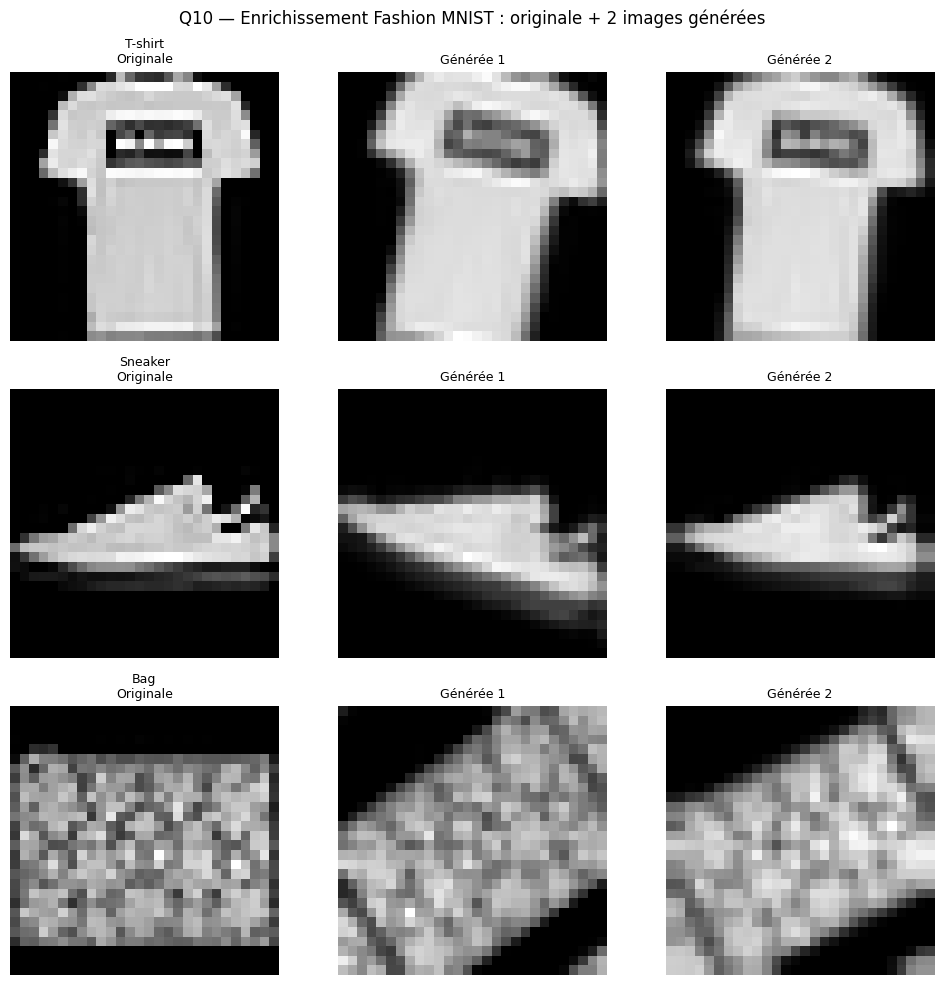

Images générées : 6


In [19]:
# Chargement Fashion MNIST
(train_images_fm, train_labels_fm), (test_images_fm, test_labels_fm) = \
    tf.keras.datasets.fashion_mnist.load_data()

train_images_fm = train_images_fm[..., np.newaxis] / 255.0
test_images_fm  = test_images_fm[..., np.newaxis]  / 255.0

class_names_fm = ['T-shirt','Trouser','Pullover','Dress','Coat',
                  'Sandal','Shirt','Sneaker','Bag','Ankle boot']

# Générer 2 images pour 3 classes : T-shirt (0), Sneaker (7), Bag (8)
classes_choisies = [0, 7, 8]

fig, axes = plt.subplots(3, 3, figsize=(10, 10))
fig.suptitle("Q10 — Enrichissement Fashion MNIST : originale + 2 images générées", fontsize=12)

augment = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

new_images_fm = []
new_labels_fm = []

for row, class_idx in enumerate(classes_choisies):
    idx = np.where(train_labels_fm.flatten() == class_idx)[0][0]
    original = train_images_fm[idx]

    axes[row, 0].imshow(original.squeeze(), cmap='gray')
    axes[row, 0].set_title(f"{class_names_fm[class_idx]}\nOriginale", fontsize=9)
    axes[row, 0].axis('off')

    for j in range(2):
        aug = augment(tf.expand_dims(tf.cast(original, tf.float32), 0), training=True)
        aug = np.clip(tf.squeeze(aug).numpy(), 0.0, 1.0)

        axes[row, j+1].imshow(aug.squeeze(), cmap='gray')
        axes[row, j+1].set_title(f"Générée {j+1}", fontsize=9)
        axes[row, j+1].axis('off')

        new_images_fm.append(aug)
        new_labels_fm.append(class_idx)

plt.tight_layout()
plt.savefig("enrichissement_fashion_mnist.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"Images générées : {len(new_images_fm)}")

In [21]:
new_images_fm_array = np.array(new_images_fm)   # (6, 28, 28, 1)
new_labels_fm_array = np.array(new_labels_fm)    # (6,)

probability_model_fm = tf.keras.Sequential([model_fashion_mnist, tf.keras.layers.Softmax()])
predictions_fm = probability_model_fm.predict(new_images_fm_array)
predicted_fm = np.argmax(predictions_fm, axis=1)

correct_fm = np.sum(predicted_fm == new_labels_fm_array)
print(f"Bonnes prédictions : {correct_fm}/6")
print(f"Précision : {correct_fm/6*100:.1f}%")

for i, class_idx in enumerate(classes_choisies):
    mask = new_labels_fm_array == class_idx
    preds = predicted_fm[mask]
    correct = np.sum(preds == class_idx)
    print(f"{class_names_fm[class_idx]:12s} : {correct}/2 correctes "
          f"(prédit : {[class_names_fm[p] for p in preds]})")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 869ms/step
Bonnes prédictions : 5/6
Précision : 83.3%
T-shirt      : 2/2 correctes (prédit : ['T-shirt', 'T-shirt'])
Sneaker      : 2/2 correctes (prédit : ['Sneaker', 'Sneaker'])
Bag          : 1/2 correctes (prédit : ['Bag', 'T-shirt'])
